In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_step1.csv")

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
print(df.shape)

df.info()

(518596, 8)
<class 'pandas.DataFrame'>
RangeIndex: 518596 entries, 0 to 518595
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      518596 non-null  str    
 1   StockCode    518596 non-null  str    
 2   Description  515668 non-null  str    
 3   Quantity     518596 non-null  int64  
 4   InvoiceDate  518596 non-null  str    
 5   Price        518596 non-null  float64
 6   Customer ID  410763 non-null  float64
 7   Country      518596 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 31.7 MB


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_step1.csv")

# Create Revenue column
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [6]:
print(df["Revenue"].describe())

count    518596.000000
mean         18.329828
std         161.380401
min      -53594.360000
25%           3.750000
50%          10.080000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64


In [7]:
print(df["Revenue"].describe())

count    518596.000000
mean         18.329828
std         161.380401
min      -53594.360000
25%           3.750000
50%          10.080000
75%          17.700000
max       25111.090000
Name: Revenue, dtype: float64


In [8]:
top_products = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Description
WHITE HANGING HEART T-LIGHT HOLDER    57632
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54554
BROCADE RING PURSE                    47647
PACK OF 72 RETRO SPOT CAKE CASES      46079
ASSORTED COLOUR BIRD ORNAMENT         44805
60 TEATIME FAIRY CAKE CASES           36172
PACK OF 60 PINK PAISLEY CAKE CASES    31687
JUMBO BAG RED RETROSPOT               30668
SMALL POPCORN HOLDER                  29485
STRAWBERRY CERAMIC TRINKET BOX        26496
Name: Quantity, dtype: int64

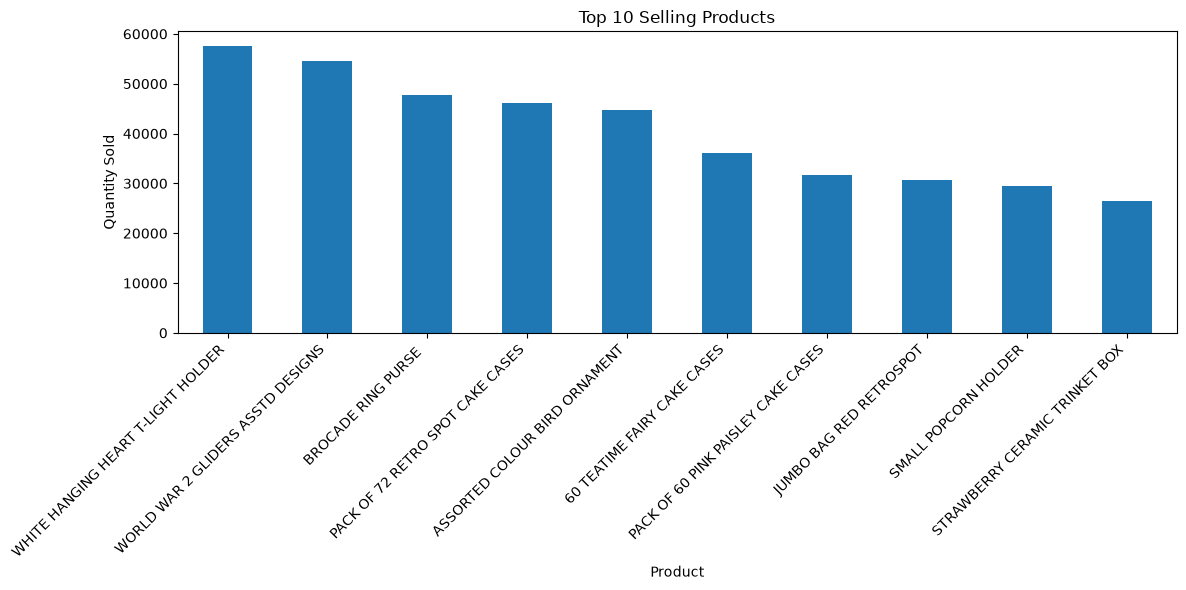

In [9]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [10]:
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue

Description
REGENCY CAKESTAND 3 TIER               162885.71
WHITE HANGING HEART T-LIGHT HOLDER     157580.28
DOTCOM POSTAGE                         116401.99
ASSORTED COLOUR BIRD ORNAMENT           72251.32
PAPER CHAIN KIT 50'S CHRISTMAS          57808.25
JUMBO BAG RED RETROSPOT                 56329.56
PARTY BUNTING                           49626.92
ROTATING SILVER ANGELS T-LIGHT HLDR     47641.89
POSTAGE                                 46092.36
JUMBO BAG STRAWBERRY                    36668.41
Name: Revenue, dtype: float64

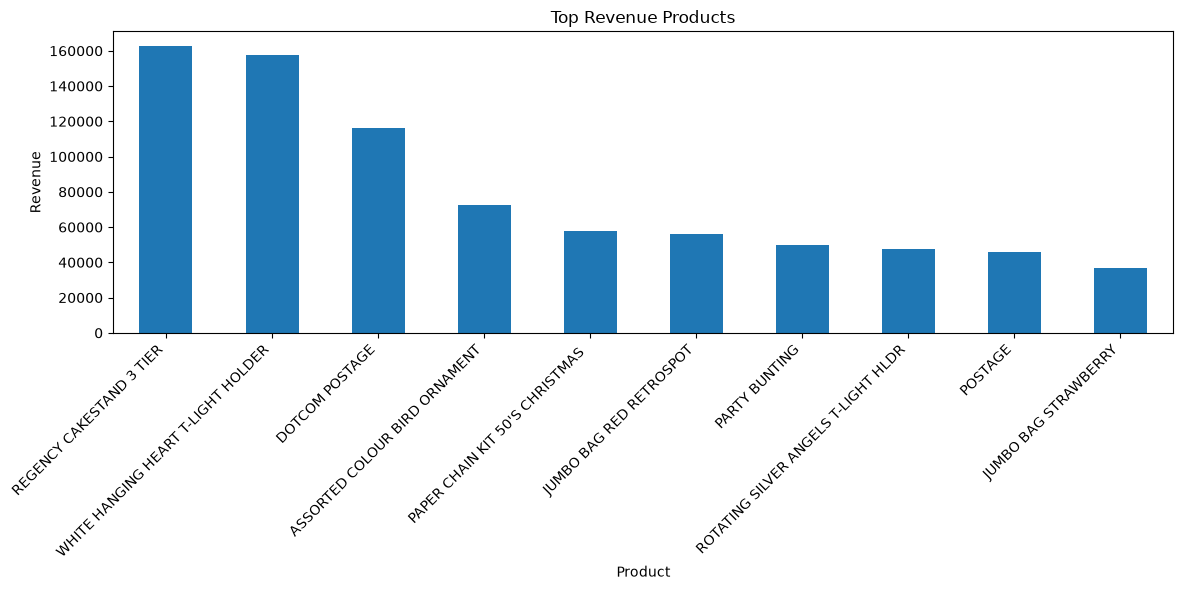

In [11]:
plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar")

plt.title("Top Revenue Products")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

In [12]:
top_customers = (
    df.groupby("Customer ID")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

Customer ID
18102.0    341776.73
14646.0    243853.05
14156.0    183163.55
14911.0    137710.76
13694.0    128172.42
17511.0     83760.60
15061.0     82162.74
16684.0     75610.17
13089.0     55801.73
16754.0     54558.18
Name: Revenue, dtype: float64

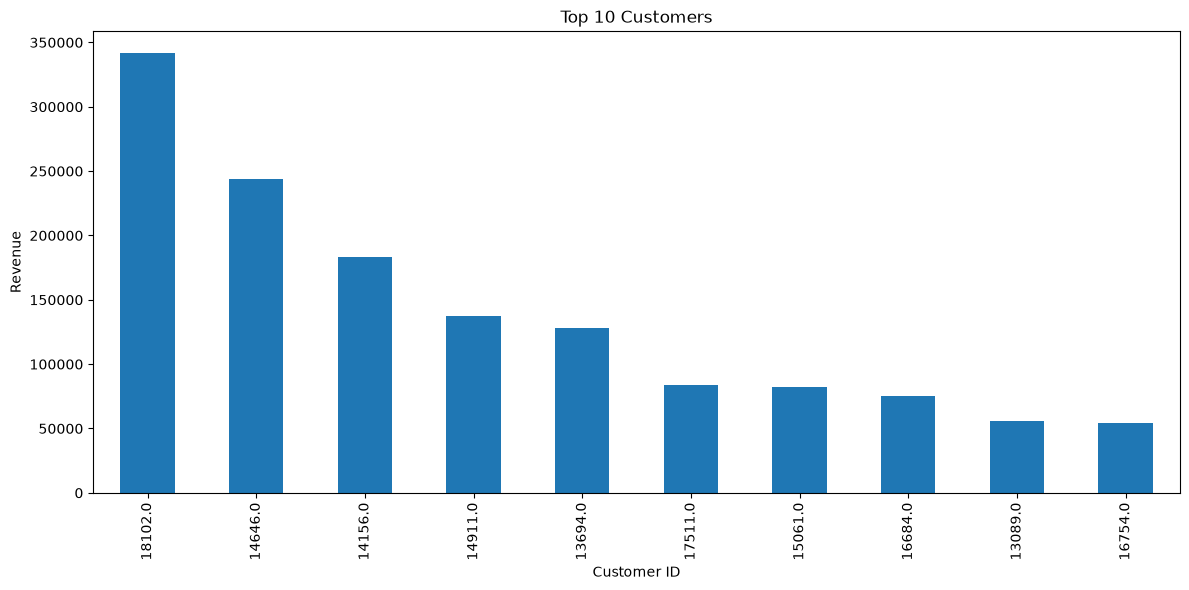

In [13]:
plt.figure(figsize=(12,6))

top_customers.plot(kind="bar")

plt.title("Top 10 Customers")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [14]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    8161692.763
EIRE               352235.680
Netherlands        263861.760
Germany            195920.421
France             130661.550
Sweden              51190.110
Denmark             46972.950
Switzerland         43343.410
Spain               37052.130
Australia           30051.800
Name: Revenue, dtype: float64

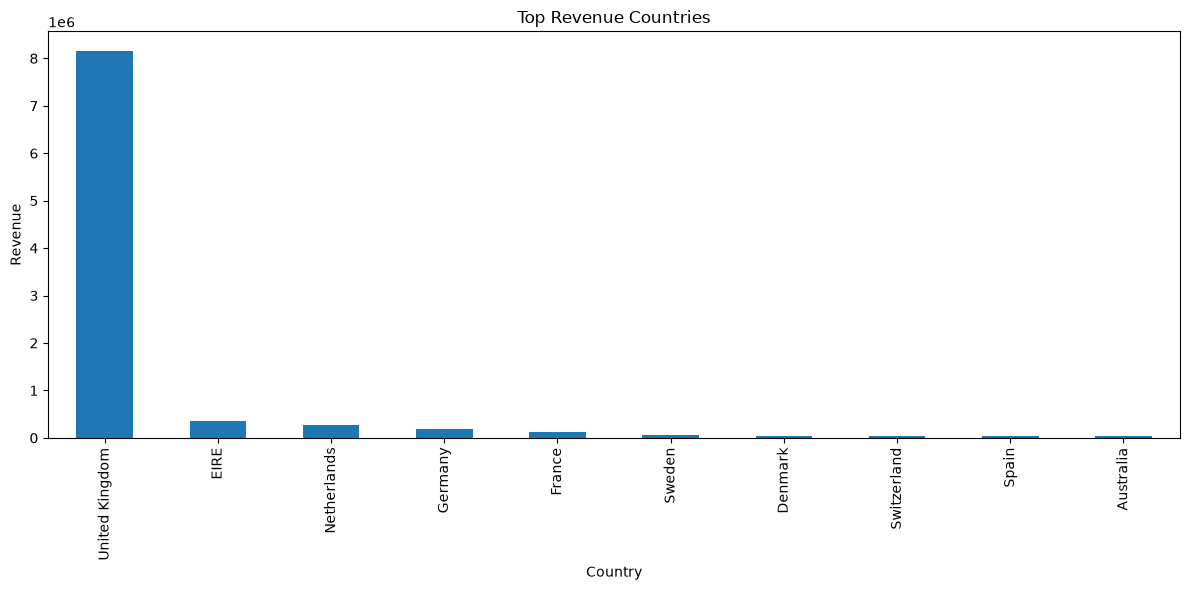

In [15]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar")

plt.title("Top Revenue Countries")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [16]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

monthly_sales

Month
2009-12     796648.500
2010-01     622479.502
2010-02     531265.366
2010-03     763247.241
2010-04     587926.692
2010-05     613270.720
2010-06     677073.870
2010-07     573333.690
2010-08     654774.390
2010-09     851105.961
2010-10    1041685.610
2010-11    1416697.202
2010-12     376266.820
Freq: M, Name: Revenue, dtype: float64

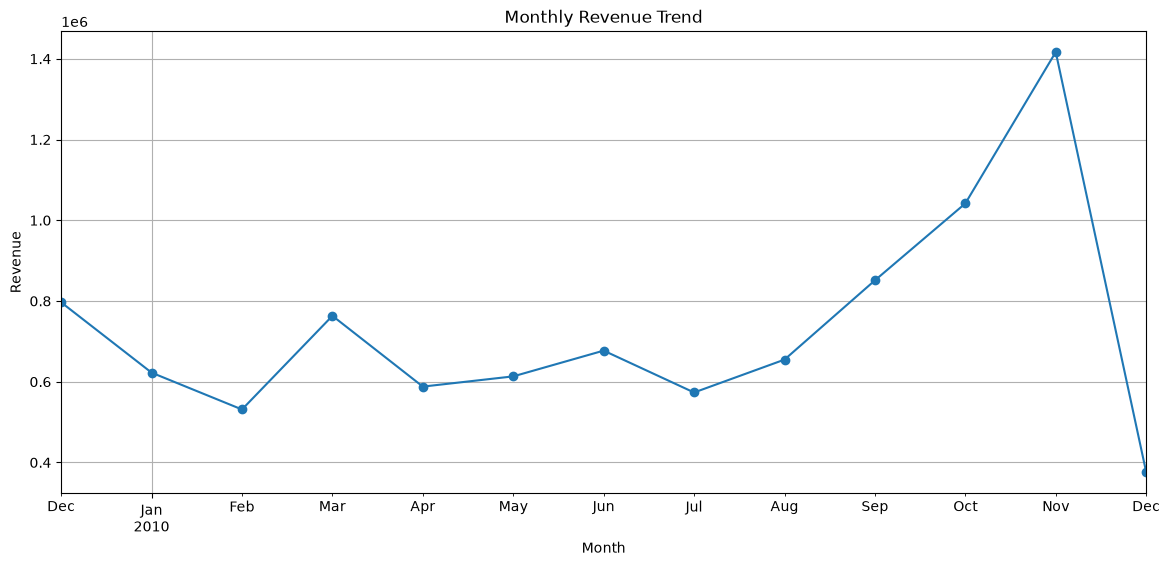

In [17]:
plt.figure(figsize=(14,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue Trend")

plt.ylabel("Revenue")

plt.grid(True)

plt.show()

## Business Insights

- White Hanging Heart T-Light Holder is the best-selling product.
- The United Kingdom contributes the highest revenue.
- A small number of customers generate a large share of revenue.
- Monthly sales show seasonal variation.